In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import numpy as np
from filterpy.kalman import KalmanFilter as KF
import pickle
from scipy import linalg
from matplotlib import pyplot as plt

import utils_data

In [3]:
dt    = 0.01
omega = 2 * np.pi * 1  # frequency = 1 Hz
q     = 20. # quality
k     = 2 * np.pi * 1.
a     = np.array([[0, 1], [-omega**2, -omega/q]])
b     = np.array([[0], [-k*omega**2]])
u     = np.array([[100.]])

kf   = KF(dim_x=2, dim_z=1)
kf.F = linalg.expm(a * dt)
kf.H = np.array([[1, 0]])
kf.B = b * dt

# initial state and covariances
kf.x = np.array([0, 0.])
kf.P *= np.eye(2)   # uncertainty about the initial condition

# --! here is the point: we assume the measurement is noisy, which is not exactly true (the sensor improved),
# --! and we overestimate our model knowledge 
kf.R *= 0.1  # measurement noise
kf.Q *= 0.01  # process uncertainty

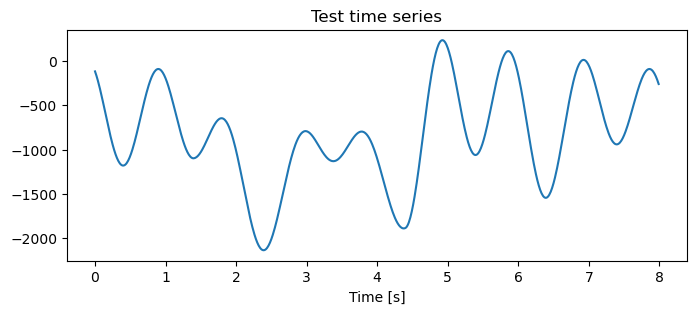

In [4]:
# --! prepare data to test a Kalman filter

timestep = 0.01
timeseries_nsample = 200
testdata = utils_data.read_datafile('../../data/kalman/test_sim/eval', timeseries_nsample).detach().numpy()

# --! test data is a batch/array with timeseries, but we want one long timeseries, so reshape
testdata = testdata.reshape(-1, testdata.shape[-1])

t = np.arange(0., testdata.shape[0]*timestep, timestep).reshape(-1, 1)

plt.figure(figsize=(8, 3))
plt.title('Test time series')
plt.plot(t, testdata)
plt.xlabel('Time [s]')
plt.show()

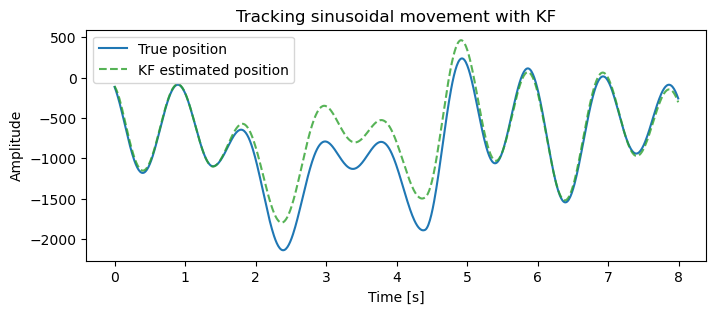

In [5]:
kf_pos = []

for j in range(testdata.shape[0]):
    # measurement
    z = testdata[j, 0]

    # Kalman filter step
    kf.predict(u=u)
    kf.update(np.array([z]))

    # store filtered position
    kf_pos.append(kf.x[0, 0])

plt.figure(figsize=(8, 3))
plt.plot(t, testdata, label='True position', color='tab:blue', alpha=1., linestyle='solid')
plt.plot(t[:, 0], kf_pos, label='KF estimated position', color='tab:green', alpha=0.8, linestyle='dashed')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Tracking sinusoidal movement with KF')
plt.show()

In [6]:
def save_object(obj, filename):
    with open(filename, 'wb') as outp:
        pickle.dump(obj, outp, pickle.HIGHEST_PROTOCOL)

save_object(kf, '../../models/kalman/kf.pkl')